# Mixture policy compression

In the previous notebook, we have observed that while action priors are powerful in explaining participants variance. However, we have also seen that Q values and action priors are not fully sufficient to explain participants behaviour, as the additional regressors from Ott's planning and hybrid model were still required to get the best fit. A possible explanation is that we have so far only considered single action priors in isolation. It is however likely that participants priors are not only defined regarding only one aspect of the task but a combination thereof. In other words, it is likely that participants consider for example both offer as well as cost to make a decision. In this notebook, we will explore this idea by devising models combining several action priors.

Just as before, following the idea that participants behaviours follows a softmax function:

$$
P(a=1|s) = \frac{\beta_1 e^{\beta Q(s,a=1) + \sum_{j=1}^{n} \theta_j log(P_j(a=i))}}{\sum_{i=1}^{k} \beta_1 e^{\beta Q(s,a=i) + \sum_{j=1}^{n} \theta_j log(P_j(a=i))}}
$$

Where $n$ is the number of distinct priors. This simplifies to:

$$
\begin{align}
P(a=1|s) &= \frac{1}{q+e^{-\eta}} \\
\eta &= \beta (Q(a=1) - Q(a=0)) + \sum_{j=1}^{n} \theta_j logit(P_j(a=1))
\end{align}
$$

We will therefore fit such mixture models, combining priors associated with offer and costs that we will then compare to the fits with and without the additional regressors from Ott's original models. We will skip the energy dimension, because we saw in the previous notebook that our homeostatic prior didn't seem to be doing much. It is surely possible to find a different parametrization for it, but for now, we will stick to what works. 

# Preparing the data

In [4]:
import numpy as np
import pandas as pd
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import arviz as az
import bambi as bmb
from scipy.special import logit


# ===================================================================
# Loading the raw data:
data = pd.read_csv("../../data/raw_data/all_participants_data.csv", on_bad_lines='skip')

# ===================================================================
# Data preprocessing:
# Remove nans:
data = data.dropna()
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the dataframe:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
data['dv'] = dv_trials

# Compute offer specific decision value regressors:
data['dv_23'] = data['dv'].to_numpy() * (data['is_2'].to_numpy() + data['is_3'].to_numpy())
data['dv_14'] = data['dv'].to_numpy() * (data['is_1'].to_numpy() + data['is_4'].to_numpy())

# Compute state dependent action priors:

In [5]:
# ===================================================================
# Coarse offers prior:
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if o < 3:
        data.loc[trial_i, 'P(A)-offer'] = 0.25
    else:
        data.loc[trial_i, 'P(A)-offer'] = 0.75

# ===================================================================
# Costs prior
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if cc == 1:
        data.loc[trial_i, 'P(A)-costs'] = 0.75
    elif cc == 2:
        data.loc[trial_i, 'P(A)-costs'] = 0.25

# Convert them all to logit:
data["logitP_A_offer"] = logit(data['P(A)-offer'].to_numpy())
data["logitP_A_costs"] = logit(data['P(A)-costs'].to_numpy())

# Model fitting:

In [6]:
traces = {}

# ===================================================================
# Simple logistic hierarchical model (Benchmark):
logistic_model = bmb.Model(
    "response ~ dv + (dv|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model'] = logistic_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Planning model from Ott's (Benchmark)
planning_model = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
    "(dv + is_basic|vpn)", 
    data, 
    family="bernoulli")
traces['planning_model'] = planning_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid model from Ott's (Benchmark)
hybrid_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model'] = hybrid_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid model with offer specific action prior (for reference from previous notebook):
hybrid_model_offer = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_offer'] = hybrid_model_offer.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid model with costs specific action prior  (for reference from previous notebook):
hybrid_model_costs = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_costs'] = hybrid_model_costs.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Simple mixture model
prior_mixture_model = bmb.Model(
    "response ~ dv + logitP_A_offer + logitP_A_costs + "
    "(dv + logitP_A_offer + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['prior_mixture_model'] = prior_mixture_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Planning mixture model
planning_prior_mixture_model = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs + "
    "(dv + is_basic + logitP_A_offer + logitP_A_costs|vpn)",
    data, 
    family="bernoulli")
traces['planning_prior_mixture_model'] = planning_prior_mixture_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid mixture model
hybrid_prior_mixture_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_prior_mixture_model'] = planning_prior_mixture_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_basic, is_full_energy, is_low_energy_LC, is_low_energy_HC, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_basic|vpn_sigma, is_basic|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 69 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv_23, dv_14, is_1, is_2, is_3, is_4, is_full_energy, is_low_energy_LC, is_low_energy_HC, 1|vpn_sigma, 1|vpn_offset, dv_23|vpn_sigma, dv_23|vpn_offset, dv_14|vpn_sigma, dv_14|vpn_offset, is_1|vpn_sigma, is_1|vpn_offset, is_2|vpn_sigma, is_2|vpn_offset, is_3|vpn_sigma, is_3|vpn_offset, is_4|vpn_sigma, is_4|vpn_offset]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_basic, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_offer, logitP_A_costs, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_basic|vpn_sigma, is_basic|vpn_offset, logitP_A_offer|vpn_sigma, logitP_A_offer|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 91 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_basic, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_offer, logitP_A_costs, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_basic|vpn_sigma, is_basic|vpn_offset, logitP_A_offer|vpn_sigma, logitP_A_offer|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 90 seconds.


/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvr

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
hybrid_model_costs,0,-1605.493823,189.295913,0.000000,7.268973e-01,50.827475,0.000000,True,log
hybrid_prior_mixture_model,1,-1637.244702,146.225450,31.750880,5.689042e-14,52.296579,13.732851,False,log
planning_prior_mixture_model,2,-1637.362435,146.355795,31.868613,2.131512e-01,52.285639,13.751832,False,log
hybrid_model_offer,3,-1674.036844,161.001128,68.543022,3.498372e-14,52.065894,13.555728,True,log
hybrid_model,4,-1675.513571,158.272816,70.019748,2.354237e-14,52.106215,13.630661,True,log
prior_mixture_model,5,-1710.209995,128.945400,104.716172,5.161811e-02,52.248126,19.090162,True,log
planning_model,6,-2031.991118,90.466062,426.497295,0.000000e+00,55.162053,30.801399,False,log
logistic_model,7,-2061.856376,69.666754,456.362553,8.333357e-03,55.772261,32.077625,False,log


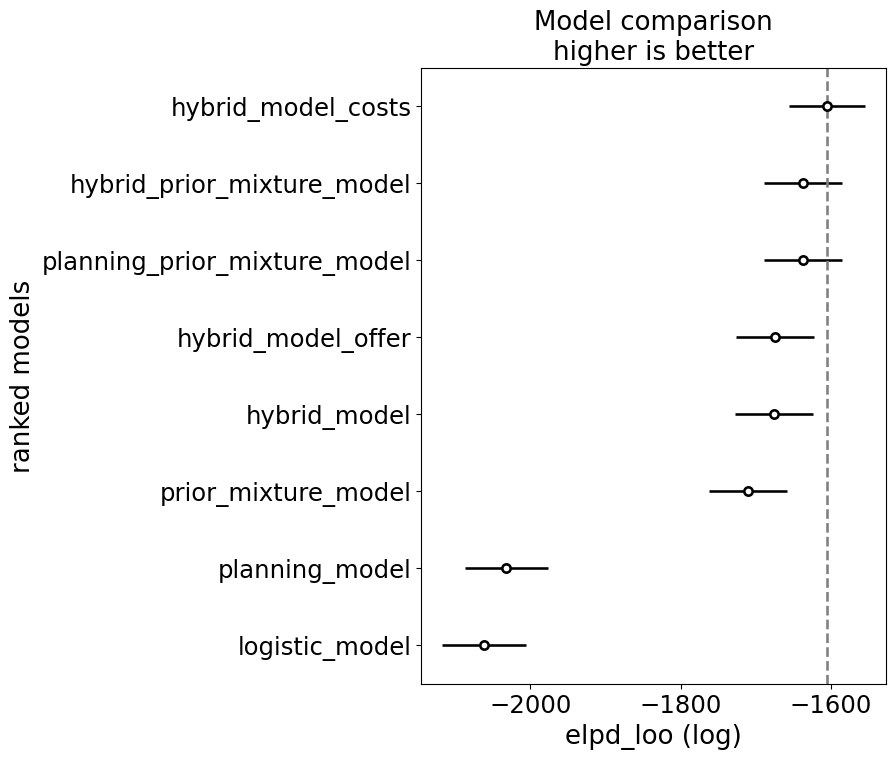

In [7]:
# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

Interestingly, the results show that the best model remains the hybrid model combined with costs specific action priors. This indicates that the increase in fit observed in both the hybrid mixture model and the planning mixture model can be explained by the effect of costs, but that ultimately, the addition of an offer prior to the hybrid model with costs action prior is irreelvant. I would have expected the planning mixture model to perform the best. The mixture planning model contains both information about offers (through the offer specific prior) and about the costs (through the costs specific action prior). I had assumed this would outperform the hybrid model with offers because eventhough both the hybrid model and the planning mixture model contain offer specific information, the planning mixture model has less parameters and therefore lower complexity.

This result once against emphasize that the information encoded in the offer prior is not fully equivalent to the offer specific information of the hybrid model. To dig a bit deeper into this, we will compare the hybrid model with costs prior against various models combining parts of the hybrid model with the offer specific action prior to identify exactly which part of the hybrid model differs from the offer prior:

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv_23, dv_14, is_1, is_2, is_3, is_4, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_costs, 1|vpn_sigma, 1|vpn_offset, dv_23|vpn_sigma, dv_23|vpn_offset, dv_14|vpn_sigma, dv_14|vpn_offset, is_1|vpn_sigma, is_1|vpn_offset, is_2|vpn_sigma, is_2|vpn_offset, is_3|vpn_sigma, is_3|vpn_offset, is_4|vpn_sigma, is_4|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 132 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_1, is_2, is_3, is_4, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_costs, logitP_A_offer, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_1|vpn_sigma, is_1|vpn_offset, is_2|vpn_sigma, is_2|vpn_offset, is_3|vpn_sigma, is_3|vpn_offset, is_4|vpn_sigma, is_4|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset, logitP_A_offer|vpn_sigma, logitP_A_offer|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 200 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv_23, dv_14, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_costs, logitP_A_offer, 1|vpn_sigma, 1|vpn_offset, dv_23|vpn_sigma, dv_23|vpn_offset, dv_14|vpn_sigma, dv_14|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset, logitP_A_offer|vpn_sigma, logitP_A_offer|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 54 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
hybrid_model_costs,0,-1606.535797,190.042064,0.000000,0.458545,50.914681,0.000000,True,log
hybrid_mixture_v1,1,-1608.707619,176.628375,2.171822,0.454791,51.005683,7.905583,True,log
hybrid_mixture_v2,2,-1642.337842,162.546460,35.802045,0.086664,52.250074,11.600193,True,log


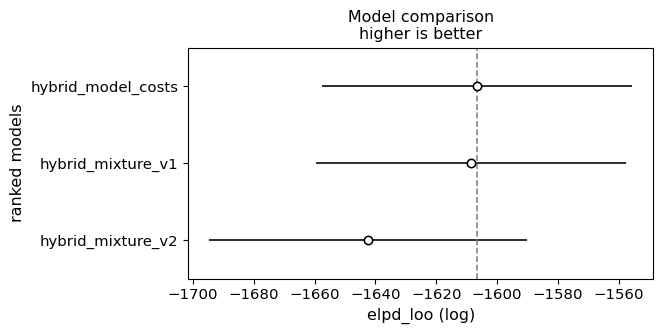

In [11]:
traces = {}

# ===================================================================
# Hybrid model with costs specific action prior (reference):
hybrid_model_costs = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_costs'] = hybrid_model_costs.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid model v1
hybrid_mixture_v1 = bmb.Model(
    "response ~ dv + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs + logitP_A_offer +"
    "(dv + is_1 + is_2 + is_3 + is_4 + logitP_A_costs + logitP_A_offer|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_mixture_v1'] = hybrid_mixture_v1.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid model v2
hybrid_mixture_v2 = bmb.Model(
    "response ~ dv_23 + dv_14 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs + logitP_A_offer +"
    "(dv_23 + dv_14 + logitP_A_costs + logitP_A_offer|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_mixture_v2'] = hybrid_mixture_v2.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

# Discussion

The V1 model combines both the offer and the costs dependent prio with offer specific constants but gets rid of the separation between the weights of the decision value for high and low offer and performs equally well as teh hybrid costs model. These results indicate that what isn't covered by the offer prior is the fact that participants seem to show offer specific bias. This is quite interesting, as in the previous notebook, we observed that a finer grain offer prior does not perform as good as a prior chunking offers into high and low. These results suggest that participants kind of do both: chunk offers roughly into high and low but also exhibit offer specific biases. 

One potential explanation is that participants might start off the task by grouping offers in high and low and use a weighting of the decision value and that prior on a given trial. But then, as the more extreme offers (1 and 4) typically have decision values that are much higher, these end up dominating the decision, leading the marginal probability of accepting on these specific offers to drift from that initial prior compared to the intermediate offer. In fact, it is a critical aspects of policy compression that the marginal probability of each action changes dynamically over time. This is what we will explore in the next notebook. 